# Modelling infiltration into variably saturated, variably frozen soil

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pl

In [2]:
from soilice import model
from soilice import save, loadModel

In [3]:
from soilice import writeDefaultPars
writeDefaultPars()

def_pars.txt already exists in local folder


In [4]:
from matplotlib.gridspec import GridSpec
def irrigationPlot(out):

    t,z,psie,psif,T,thetaL,thetaI,qI,qT,qB,jT,jB=(
        out.t,
        out.z,
        out.psie,
        out.psif,
        out.T,
        out.thetaL,
        out.thetaI,
        out.qI,
        out.qT,
        out.qB,
        out.jT,
        out.jB
    )
    i=np.arange(0,len(t),15)
    
    # --- Create figure and layout ---
    fig = pl.figure(figsize=(6,5))
    gs = GridSpec(3, 2, figure=fig)
    
    ax1 = fig.add_subplot(gs[0, :])
    # ax2 = fig.add_subplot(gs[1:, 0])
    ax3 = fig.add_subplot(gs[1:, 0])
    ax4 = fig.add_subplot(gs[1:, 1])
    
    # --- Top plot (fluxes) ---
    ax1.plot(t, qT/dt*1000, 'r', lw=2, label='Infiltration')
    ax1.plot(t, qB/dt*1000, 'g', lw=2, label='Drainage')
    ax1.plot(t, qI*1000, 'b', label='Applied irrigation')
    ax1.plot(t, (qI-qT/dt)*1000, color='orange', label='Runoff')
    ax1.set_ylim(0, 60)
    ax1.set_xlim(t[0], t[-1])    
    # ax1.legend(loc=1)
    ax1.grid()
    ax1.set_ylabel("Flux (mm/d)")
    ax1.set_xlabel('Time (d)')
    fig.suptitle(out.title)
    
    # # --- Left plot (potentials) ---
    # ax2.plot(psif[0,:].T, z, 'c', lw=2, label='Frozen potential')
    # ax2.plot(psie[0,:].T, z, 'b', lw=2, label='Matric potential')
    # ax2.plot(psif[i,:].T, z, 'c', lw=1)
    # ax2.plot(psie[i,:].T, z, 'b', lw=1)
    # # line_h, = ax2.plot([], z, 'g')
    # ax2.set_ylim(2, 0)
    # ax2.set_xlim(-6, 0)
    # ax2.set_xlabel('Head (m)')
    ax3.set_ylabel('Depth (m)')
    # ax2.legend(loc=3)
    # ax2.grid()
    
    # --- Middle plot (water content) ---
    ax3.plot(thetaL[0,:].T, z, 'b', lw=2, label='Liquid')
    ax3.plot(thetaI[0,:].T, z, 'c', lw=2, label='Ice')
    ax3.plot(thetaL[i,:].T, z, 'b', lw=1)
    ax3.plot(thetaI[i,:].T, z, 'c', lw=1)
    ax3.set_ylim(2, 0)
    ax3.set_xlim(0, 0.5)
    ax3.set_yticklabels([])
    ax3.set_xlabel('Water content (-)')
    ax3.legend(loc=3)
    ax3.grid()
    
    # --- Right plot (temperature) ---
    ax4.plot(T[0,:].T, z, 'r', lw=2, label='Temperature')
    ax4.plot(T[i,:].T, z, 'r', lw=1)
    ax4.set_ylim(2, 0)
    ax4.set_xlim(-5.5,1.5)
    ax4.set_yticklabels([])
    ax4.set_xlabel('Temperature (°C)')
    ax4.grid()
    
    # --- Adjust spacing ---
    pl.subplots_adjust(wspace=0.05, hspace=0.6)

In [5]:
# Soil model options:
# Soil model options:
opts={'simulateFlow': 1.0,        # simulate flow
 'gravity': 1.0,                  # gravity on (vertical flow)
 'infiltration': 1.0,             # Potential infiltration upper BC
 'cryoK': 0.0,                    # Hydraulic conductivity based on total water content 
 'cryoGradient': 0.0,                 # Cryosuction gradient not used
 'freeDrainage': 1.0,             # Free drainage lowed BC
 'simulateTransport': 1.0,        # simulate transport
 'withadv': 1.0,                  # Simulate advection
 'conductionTop': 0.0,            # No conduction at the top
 'conductionBot': 0.0}            # or the bottom

In [6]:
# Space grid
zMax=2.
dz=0.01
z=np.arange(dz/2,zMax,dz)
nz=len(z)
dz=np.zeros(nz)+dz

# Time grid
t=np.arange(0,20,0.1) # days
nt=len(t)
dt=t[1]-t[0]

In [7]:
sim=model(opts,rtol=1e-8)
sim.zGrid(np.hstack([0,np.cumsum(dz)]))
sim.tGrid(t[0],t[-1],t[1]-t[0])
sim.readPars()
sim.pars['impedance']=10.

In [8]:
sim.pars

{'thetaR': 0.218,
 'thetaS': 0.52,
 'alpha': 1.15,
 'n': 2.03,
 'eta': 0.5,
 'Ks': 0.316,
 'neta': 0.5,
 'Ss': 1e-06,
 'm': 0.5073891625615763,
 'theta_org': 0.0,
 'theta_mineral': 0.48,
 'cp_soil': 850.0,
 'cp_org': 580.0,
 'kappa_soil': 250560.0,
 'kappa_org': 21600.0,
 'rho_soil': 2600.0,
 'rho_org': 1300.0,
 'q': 0.0,
 'impedance': 10.0}

In [9]:
sim.printOpts()

*************************************************************************
     SUMMARY OF MODEL OPTIONS:
     * Simulating flow
     * Vertical flow
     * Infiltration at ground surface
     * Hydraulic conductivity based on total water content
     * No cryosuction
     * Free draining lower boundary condition
     * Simulating heat transport
     * Included heat advection
     * No conduction on the upper boundary
     * No conduction on the lower boundary
*************************************************************************




                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

*************************************************************************
     soilice ran successfully!
               runtime:      11.07 seconds


     Mass balance rmse:  2.60e-03 kg
                  bias:  3.01e-03 kg
   Energy balance rmse:  1.05e+00 J
                  bias:  1.18e+00 J
*************************************************************************



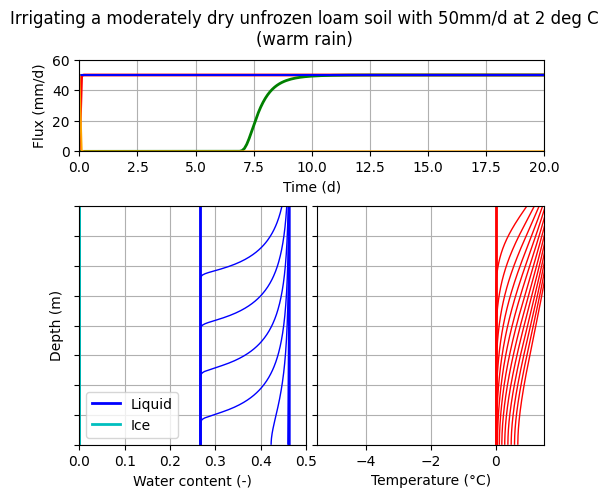

In [10]:
title=f"Irrigating a moderately dry unfrozen loam soil with 50mm/d at 2 deg C\n(warm rain)"

sim.setBCs(qI=0.05,TInf=2)
sim.setICs(psi0=-5,T0=0)

out=sim.run()
out.title=title
# save('modelRuns/02_Irrigation01.dill',out)

irrigationPlot(out)
pl.savefig('figures/02_Irrigation01.png')

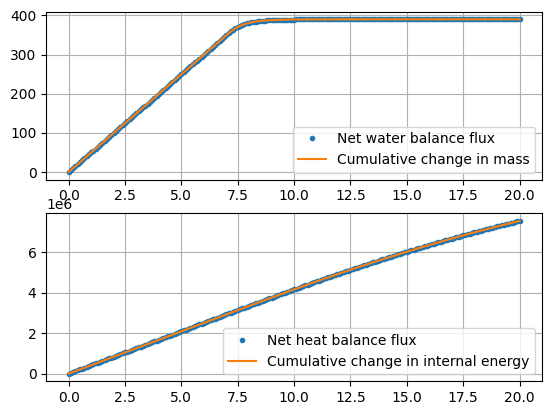

In [11]:
out.plotBalance()


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

*************************************************************************
     soilice ran successfully!
               runtime:      2.83 seconds
     Mass balance rmse:  3.05e-03 kg
                  bias:  3.70e-03 kg
   Energy balance rmse:  1.23e+03 J
                  bias:  1.46e+03 J
*************************************************************************



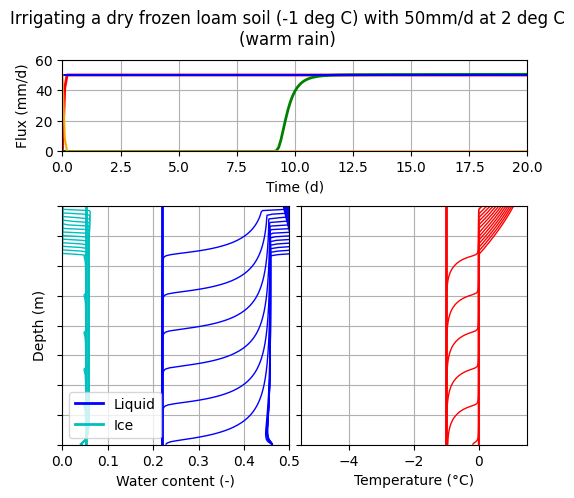

In [12]:
title=f"Irrigating a dry frozen loam soil (-1 deg C) with 50mm/d at 2 deg C\n(warm rain)"

sim.setBCs(qI=0.05,TInf=2)
sim.setICs(psi0=-5,T0=-1)

out=sim.run()
out.title=title
# save('modelRuns/02_Irrigation02.dill',out)

irrigationPlot(out)
pl.savefig('figures/02_Irrigation02.png')

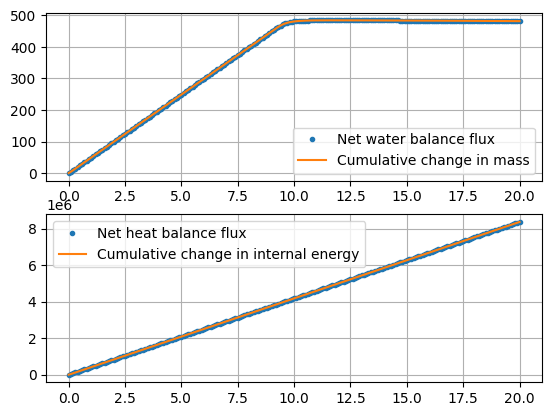

In [13]:
out.plotBalance()


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

*************************************************************************
     soilice ran successfully!
               runtime:      1.44 seconds
     Mass balance rmse:  2.98e-03 kg
                  bias:  3.88e-03 kg
   Energy balance rmse:  1.63e+03 J
                  bias:  2.05e+03 J
*************************************************************************



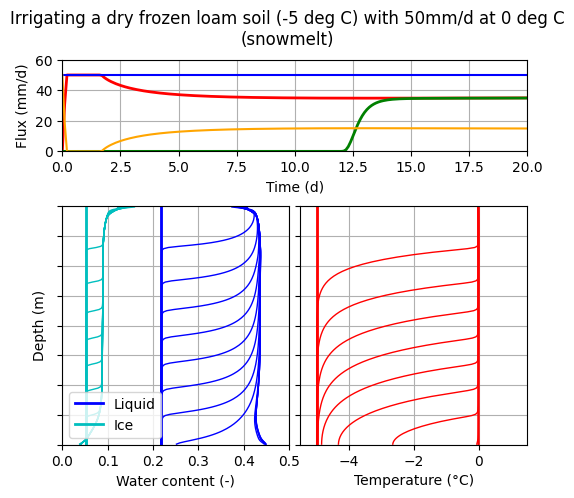

In [14]:
title=f"Irrigating a dry frozen loam soil (-5 deg C) with 50mm/d at 0 deg C\n(snowmelt)"

sim.setBCs(qI=0.05,TInf=0)
sim.setICs(psi0=-5,T0=-5)

out=sim.run()
out.title=title
# save('modelRuns/02_Irrigation03.dill',out)

irrigationPlot(out)
pl.savefig('figures/02_Irrigation03.png')

In [15]:
np.maximum(np.array([1,2,3,3,2,1,0,-1,-2]),0)

array([1, 2, 3, 3, 2, 1, 0, 0, 0])

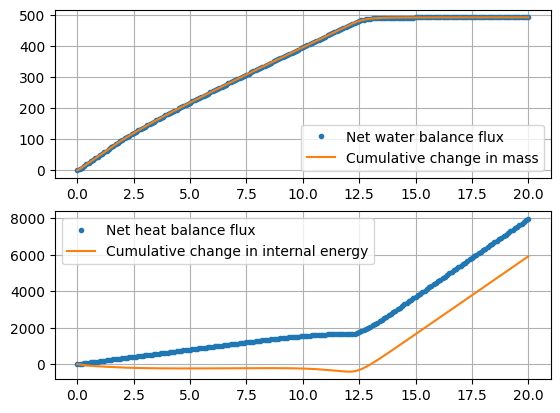

In [16]:
out.plotBalance()


                                    iiii  lllllll   iiii
                                   i::::i l:::::l  i::::i
                                    iiii  l:::::l   iiii
                                          l:::::l
    ssssssssss      ooooooooooo   iiiiiii  l::::l iiiiiii     cccccccccccccccc    eeeeeeeeeeee
  ss::::::::::s   oo:::::::::::oo i:::::i  l::::l i:::::i   cc:::::::::::::::c  ee::::::::::::ee
ss:::::::::::::s o:::::::::::::::o i::::i  l::::l  i::::i  c:::::::::::::::::c e::::::eeeee:::::ee
s::::::ssss:::::so:::::ooooo:::::o i::::i  l::::l  i::::i c:::::::cccccc:::::ce::::::e     e:::::e
 s:::::s  ssssss o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::eeeee::::::e
   s::::::s      o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e:::::::::::::::::e
      s::::::s   o::::o     o::::o i::::i  l::::l  i::::i c:::::c             e::::::eeeeeeeeeee
ssssss   s:::::s o::::o     o::::o i::::i  l::::l  i::::i c::::::c     ccccccce:::::::e
s::::

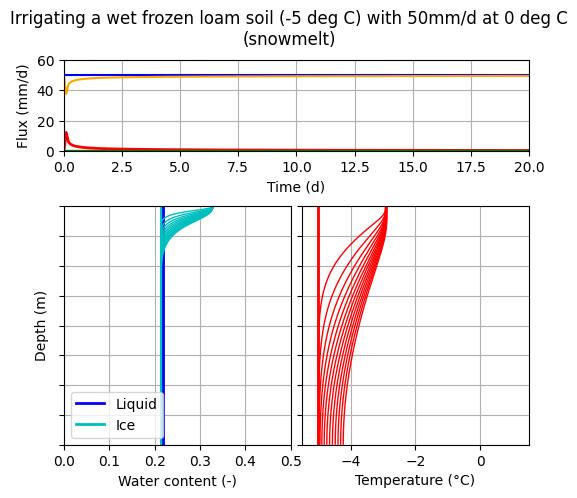

In [17]:
title=f"Irrigating a wet frozen loam soil (-5 deg C) with 50mm/d at 0 deg C\n(snowmelt)"

sim.setBCs(qI=0.05,TInf=0)
sim.setICs(psi0=-1,T0=-5)

out=sim.run()
out.title=title
# save('modelRuns/02_Irrigation04.dill',out)

irrigationPlot(out)
pl.savefig('figures/02_Irrigation04.png')

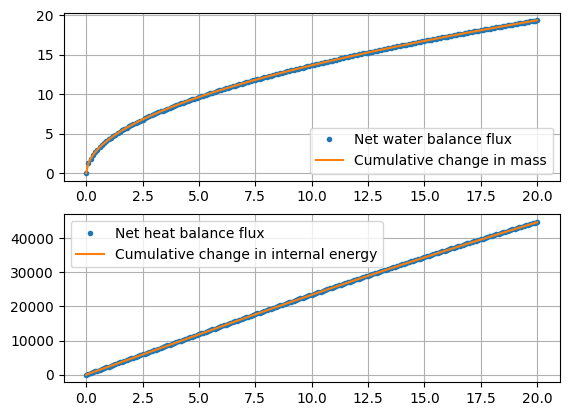

In [18]:
out.plotBalance()